# Skin Disease Classification Using EfficientNet

### Description:

The **Skin Disease Classification System** is an application based on deep learning and computer vision techniques, designed to classify skin disease images. The model is built using **EfficientNet-B0**, a convolutional neural network, to accurately classify skin disease images into **20 different categories**.

The trained model can predict skin diseases from unseen images and report both the predicted class and confidence score.

### Key Features:
- Multi-class skin disease classification (20 classes)
- EfficientNet-B0 pretrained CNN architecture
- Class imbalance handling using weighted loss
- Confusion matrix and classification report analysis
- Single-image prediction with confidence score



In [ ]:
!pip install opendatasets
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=382a571f79afe4512ec4268cac41bc3a687125cccd5f03f63afe112044931f57
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet_pytorch


# 1. Download the dataset

In [ ]:
import opendatasets as od

dataset_url = 'https://www.kaggle.com/datasets/pacificrm/skindiseasedataset'
od.download(dataset_url)

Dataset URL: https://www.kaggle.com/datasets/pacificrm/skindiseasedataset


100%|██████████| 1.36G/1.36G [01:20<00:00, 18.2MB/s]


In [ ]:
!rm -rf /content/skindiseasedataset/SkinDisease/SkinDisease/train/Benign_tumors
!rm -rf /content/skindiseasedataset/SkinDisease/SkinDisease/test/Benign_tumors
!rm -rf /content/skindiseasedataset/SkinDisease/SkinDisease/train/Eczema
!rm -rf /content/skindiseasedataset/SkinDisease/SkinDisease/test/Eczema

# 2. Import libraries

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from efficientnet_pytorch import EfficientNet
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 3. Prepare Skin Disease Image Dataset for Deep Learning

This section prepares the dataset for training a deep learning model for skin disease classification using PyTorch.  
It includes image transformations, dataset loading, and data loader creation.

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 16
DATA_DIR = '/content/skindiseasedataset/SkinDisease/SkinDisease/'

train_transform = transforms.Compose([
    transforms.RandomResizedCrop( 224, scale=(0.7, 1.0), ratio=(0.9, 1.1) ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter( brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02 ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [ ]:
class_names = train_ds.classes
print(f"Loaded {len(train_ds)} training and {len(val_ds)} test images")
print(f"Number of classes: {len(class_names)} → {class_names}")

Loaded 11795 training and 1313 test images
Number of classes: 20 → ['Acne', 'Actinic_Keratosis', 'Bullous', 'Candidiasis', 'DrugEruption', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


# 4. Visualize Class Distribution in Training Set

This section creates a bar chart to visualize the number of images for each skin disease class in the training dataset.  

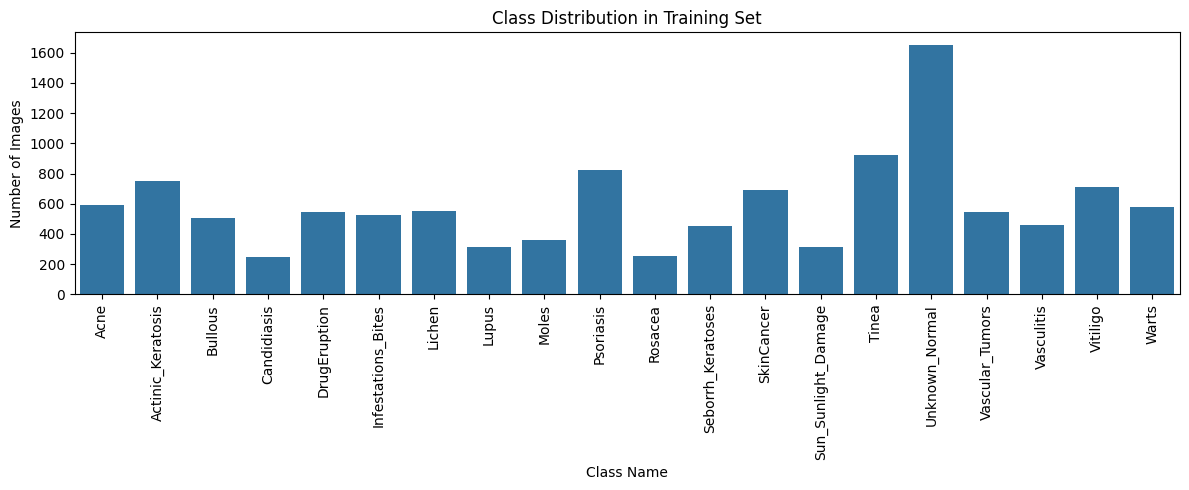

In [ ]:
import seaborn as sns
from collections import Counter

# Class distribution bar chart
label_counts = Counter(train_ds.targets)
plt.figure(figsize=(12, 5))
sns.barplot(x=[class_names[i] for i in label_counts.keys()], y=list(label_counts.values()))
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.xlabel("Class Name")
plt.tight_layout()
plt.show()

# 5. Compute Class Weights for Imbalance

This section calculates class weights to handle class imbalance in the dataset.

If some classes (diseases) have many more samples than others, the model may develop tendency to predict majority classes.

These class weights can be passed to the loss function during model training to improve performance on minority classes.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import numpy as np
labels = [label for _, label in train_ds.samples]
class_weights = compute_class_weight('balanced', classes=np.arange(len(train_ds.classes)), y=labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", class_weights)

Class weights: tensor([0.9945, 0.7884, 1.1701, 2.3780, 1.0782, 1.1255, 1.0665, 1.8963, 1.6337,
        0.7192, 2.3219, 1.2962, 0.8510, 1.8902, 0.6389, 0.3572, 1.0861, 1.2793,
        0.8260, 1.0168], device='cuda:0')


# 6. Visualize Sample Images

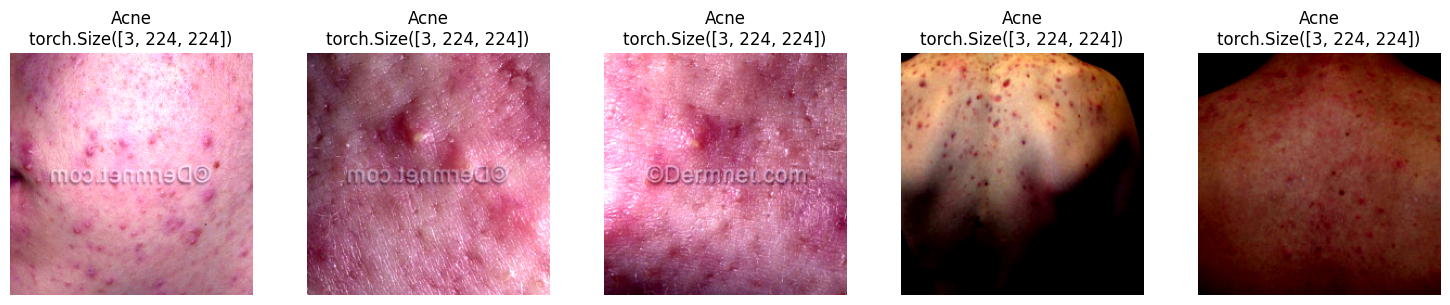

In [ ]:
# Visual check of sample images (with titles and shape info)
def visualize_samples(dataset, n=5):
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        image, label = dataset[i]
        img_display = image.permute(1, 2, 0).numpy() * 0.5 + 0.5
        axes[i].imshow(img_display)
        axes[i].set_title(f"{class_names[label]}\n{image.shape}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

visualize_samples(train_ds)

# 7. Define Model, Loss Function, Optimizer & Scheduler
- Initialize EfficientNet-B0 model with pretrained weights for skin disease classification.

- Set up CrossEntropyLoss as loss function with class weights to handle imbalance.

- Configure AdamW optimizer for efficient gradient updates.

- Add a CosineAnnealingLR scheduler to adjust learning rate dynamically during training.

In [ ]:
model = EfficientNet.from_pretrained('efficientnet-b0', num_classes=len(train_ds.classes))
model.to(device)

criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 38.7MB/s]

Loaded pretrained weights for efficientnet-b0


# 8. Implement Training Loop
This section implements the training and validation loop for the EfficientNet model, and saving the best-performing model.


Epoch 01/30 | Train Loss: 2.6028 | Val Loss: 2.0993 | Train Acc: 0.3166 | Val Acc: 0.5453 | LR: 0.000100
📌 Best model saved.
Epoch 02/30 | Train Loss: 2.1954 | Val Loss: 1.8771 | Train Acc: 0.4761 | Val Acc: 0.5986 | LR: 0.000100
📌 Best model saved.
Epoch 03/30 | Train Loss: 2.0273 | Val Loss: 1.7896 | Train Acc: 0.5401 | Val Acc: 0.6375 | LR: 0.000099
📌 Best model saved.
Epoch 04/30 | Train Loss: 1.8532 | Val Loss: 1.6836 | Train Acc: 0.6085 | Val Acc: 0.6824 | LR: 0.000098
📌 Best model saved.
Epoch 05/30 | Train Loss: 1.7758 | Val Loss: 1.6654 | Train Acc: 0.6374 | Val Acc: 0.6801 | LR: 0.000096
Epoch 06/30 | Train Loss: 1.7104 | Val Loss: 1.6588 | Train Acc: 0.6668 | Val Acc: 0.6969 | LR: 0.000093
📌 Best model saved.
Epoch 07/30 | Train Loss: 1.6509 | Val Loss: 1.6209 | Train Acc: 0.6925 | Val Acc: 0.7060 | LR: 0.000090
📌 Best model saved.
Epoch 08/30 | Train Loss: 1.6018 | Val Loss: 1.5738 | Train Acc: 0.7163 | Val Acc: 0.7411 | LR: 0.000087
📌 Best model saved.
Epoch 09/30 | Train 

<Figure size 640x480 with 0 Axes>

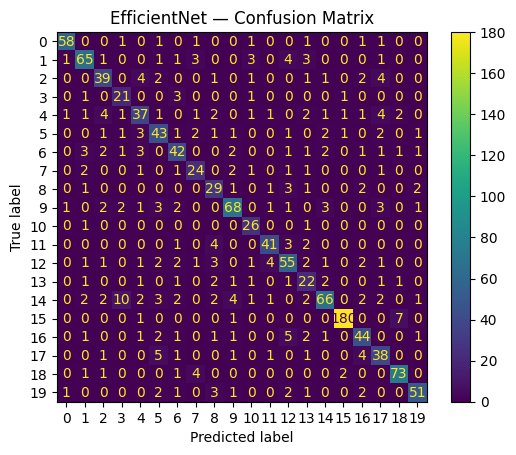

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.89      0.91        65
           1       0.81      0.78      0.80        83
           2       0.72      0.71      0.72        55
           3       0.57      0.78      0.66        27
           4       0.67      0.61      0.64        61
           5       0.66      0.72      0.69        60
           6       0.70      0.69      0.69        61
           7       0.67      0.71      0.69        34
           8       0.60      0.72      0.66        40
           9       0.82      0.77      0.80        88
          10       0.70      0.93      0.80        28
          11       0.82      0.80      0.81        51
          12       0.71      0.71      0.71        77
          13       0.51      0.65      0.57        34
          14       0.84      0.65      0.73       102
          15       0.97      0.95      0.96       189
          16       0.72      0.73      0.73        60
   

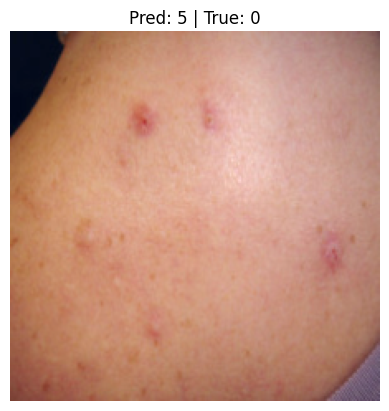

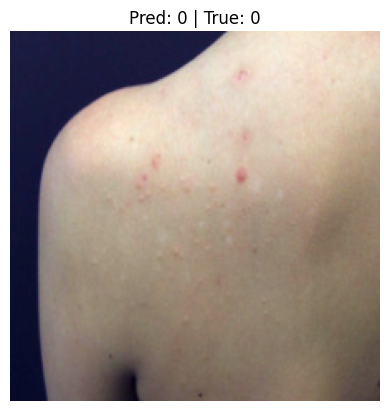

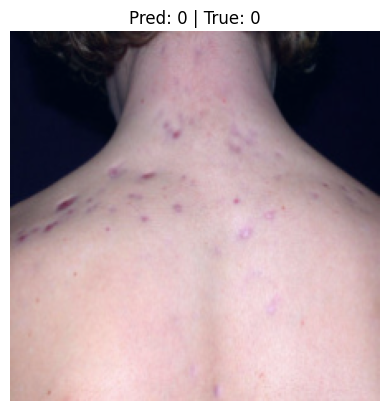

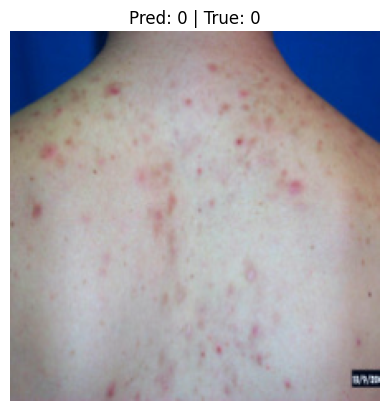

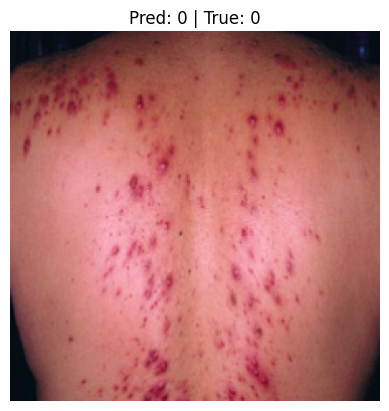

In [ ]:
# ================== COMPLETE TRAINING + VISUALIZATIONS ==================

import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

EPOCHS = 30
best_val_acc = 0
checkpoint_path = "best_efficientnet.pth"

# ✅ Store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
learning_rates = []

# ================== TRAINING ==================
for epoch in range(1, EPOCHS+1):

    # ---- TRAIN ----
    model.train()
    train_loss = train_correct = train_total = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        train_correct += preds.eq(labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---- VALIDATION ----
    model.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_acc)

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    learning_rates.append(current_lr)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}")

    # ---- CHECKPOINT ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), checkpoint_path)
        print("📌 Best model saved.")

# Load best model
model.load_state_dict(torch.load(checkpoint_path))
print("✅ Training complete; best model loaded.")


# ================== GET ALL PREDICTIONS ==================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


# ================== CLASSIFICATION REPORT ==================
print("Classification Report:\n")
print(classification_report(all_labels, all_preds))


# ================== SAMPLE PREDICTIONS ==================
imgs, labels = next(iter(val_loader))
imgs = imgs.to(device)

outputs = model(imgs)
_, preds = outputs.max(1)

imgs = imgs.cpu()

for i in range(5):
    plt.figure()
    img = imgs[i].permute(1, 2, 0)

    # Normalize image for display
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
    plt.axis('off')
    plt.show()


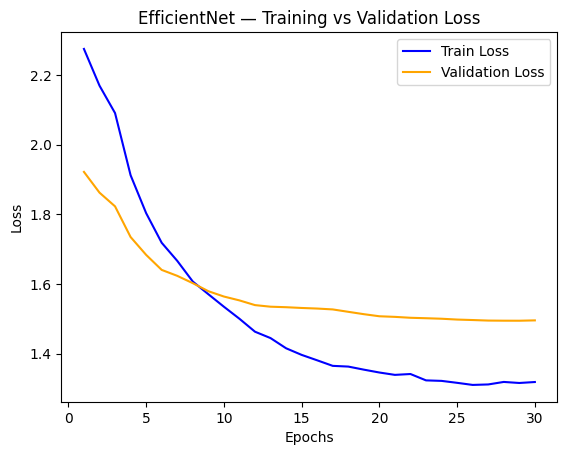

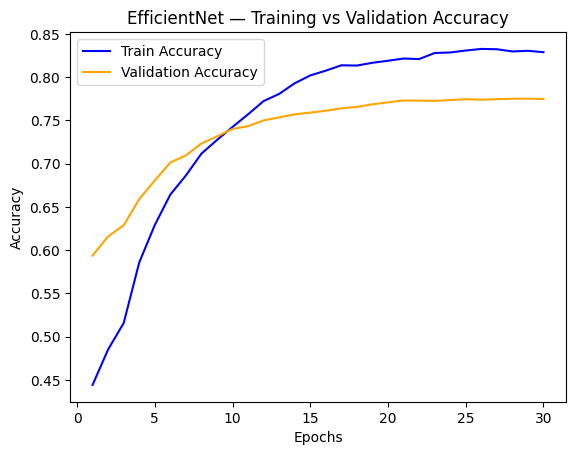

In [ ]:
# ================== LOSS CURVE ==================
epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("EfficientNet — Training vs Validation Loss")
plt.legend()
plt.show()


# ================== ACCURACY CURVE ==================
plt.figure()
plt.plot(epochs_range, train_accuracies, label="Train Accuracy", color="blue")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", color="orange")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("EfficientNet — Training vs Validation Accuracy")
plt.legend()
plt.show()

# 9. Evaluation on Test Set
This section evaluates the trained model on test set using a detailed classification report.  
The report provides precision, recall, F1-score, and support for each class.

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=train_ds.classes))


                     precision    recall  f1-score   support

               Acne       0.94      0.89      0.91        65
  Actinic_Keratosis       0.81      0.78      0.80        83
            Bullous       0.72      0.71      0.72        55
        Candidiasis       0.57      0.78      0.66        27
       DrugEruption       0.67      0.61      0.64        61
 Infestations_Bites       0.66      0.72      0.69        60
             Lichen       0.70      0.69      0.69        61
              Lupus       0.67      0.71      0.69        34
              Moles       0.60      0.72      0.66        40
          Psoriasis       0.82      0.77      0.80        88
            Rosacea       0.70      0.93      0.80        28
  Seborrh_Keratoses       0.82      0.80      0.81        51
         SkinCancer       0.71      0.71      0.71        77
Sun_Sunlight_Damage       0.51      0.65      0.57        34
              Tinea       0.84      0.65      0.73       102
     Unknown_Normal    

# 10. Confusion Matrix for Skin Disease Classification

This section evaluates the trained EfficientNet model by computing and visualizing the confusion matrix on the validation dataset.  
It helps to identify which classes are correctly predicted and which are often misclassified.


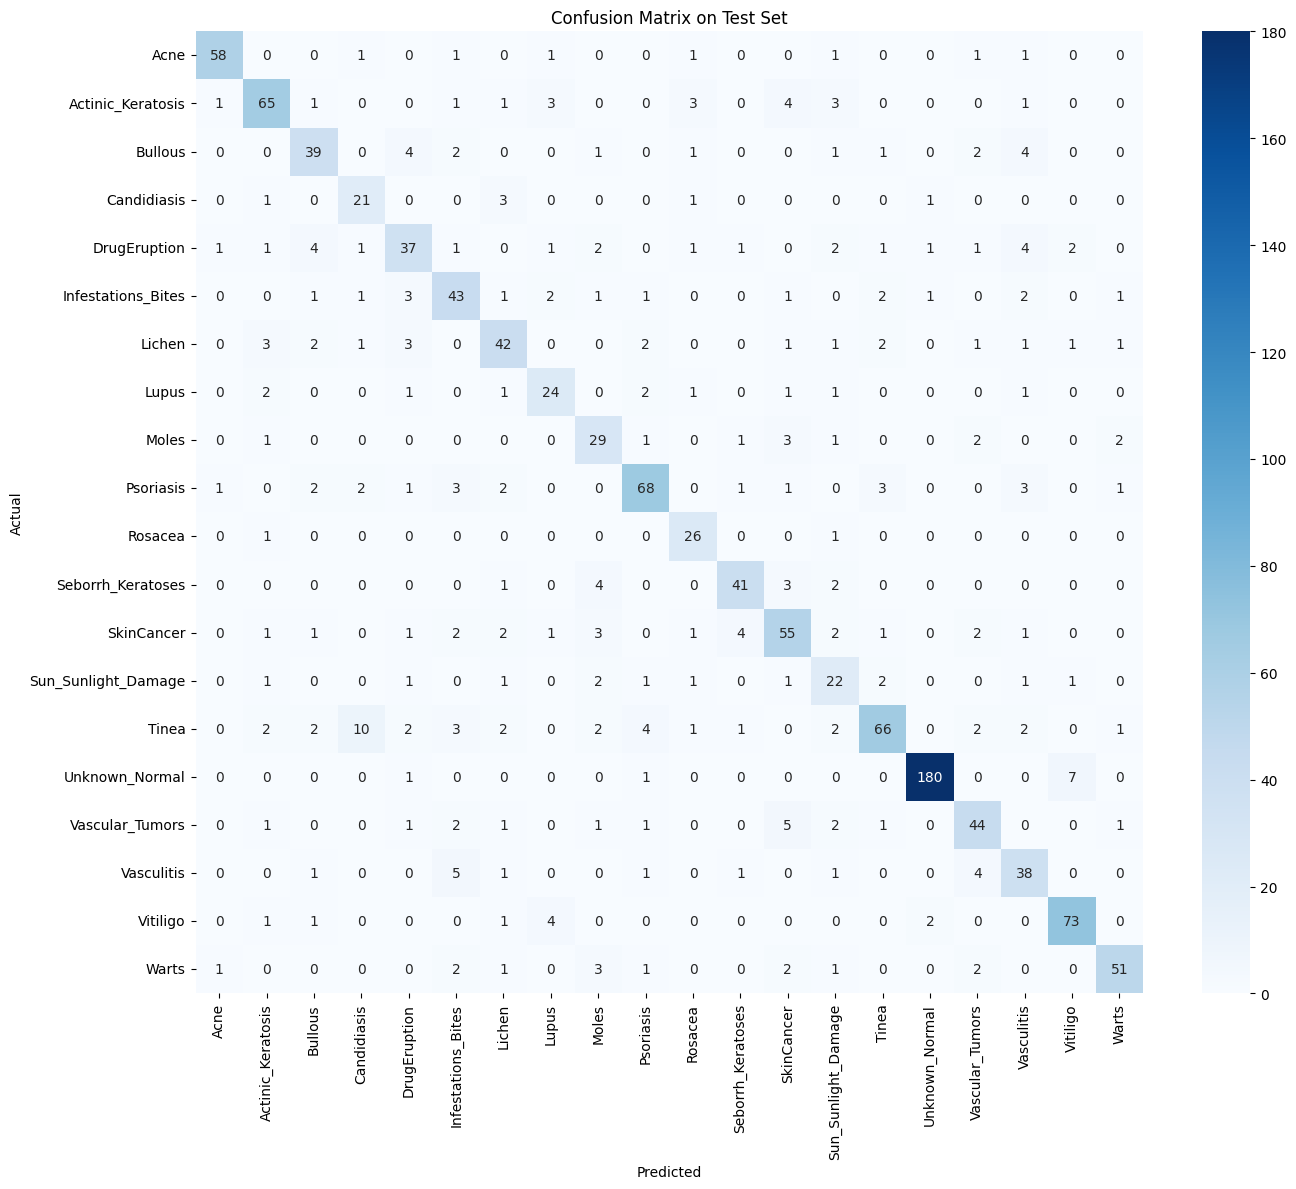

In [ ]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
labels = val_ds.classes

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix on Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 11. Prediction
This section demonstrates how to load a trained EfficientNet model and use it to predict the skin disease class for input image.



--- ORIGINAL IMAGE ---
Size: (294, 222)


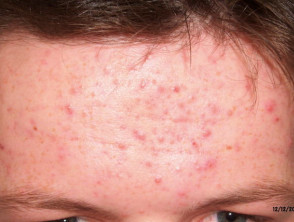


--- TENSOR INFO (AFTER TRANSFORMATION) ---
Shape (C,H,W): torch.Size([3, 224, 224])
Min value: -2.018207311630249
Max value: 2.248908281326294
Mean: 0.7020597457885742
Std: 1.1033532619476318

--- PREDICTION ---
Class: Acne
Confidence: 62.84%


In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import os
import matplotlib.pyplot as plt

# ------------------------------
# Image path
# ------------------------------
image_path = "/content/skindiseasedataset/SkinDisease/SkinDisease/test/Acne/acne-face-3-5__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDE4XQ.jpeg"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Class names
# ------------------------------
class_names = [
    'Acne', 'Actinic_Keratosis', 'Bullous', 'Candidiasis', 'DrugEruption',
    'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis',
    'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage',
    'Tinea', 'Unknown', 'Vascular_Tumors', 'Vasculitis',
    'Vitiligo', 'Warts'
]

NUM_CLASSES = len(class_names)

# ------------------------------
# Load model
# ------------------------------
model = EfficientNet.from_name("efficientnet-b0")
model._fc = torch.nn.Linear(model._fc.in_features, NUM_CLASSES)

state_dict = torch.load("/content/best_efficientnet.pth", map_location=device)
model.load_state_dict(state_dict)

model.to(device)
model.eval()

# ------------------------------
# Transform
# ------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ------------------------------
# Prediction function with debugging
# ------------------------------
def predict_single_image(image_path):

    if not os.path.exists(image_path):
        print("Image not found!")
        return

    # Load image
    image = Image.open(image_path).convert("RGB")

    print("\n--- ORIGINAL IMAGE ---")
    print("Size:", image.size)
    display(image)

    # Apply transform
    image_tensor = transform(image)

    print("\n--- TENSOR INFO (AFTER TRANSFORMATION) ---")
    print("Shape (C,H,W):", image_tensor.shape)
    print("Min value:", image_tensor.min().item())
    print("Max value:", image_tensor.max().item())
    print("Mean:", image_tensor.mean().item())
    print("Std:", image_tensor.std().item())

    # Add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1)
        confidence, pred = torch.max(probs, 1)

    prediction = class_names[pred.item()]
    confidence = confidence.item() * 100

    print("\n--- PREDICTION ---")
    print("Class:", prediction)
    print(f"Confidence: {confidence:.2f}%")

# ------------------------------
# Run prediction
# ------------------------------
predict_single_image(image_path)